# 🧠 ADS-021 — Customer Predictive Analytics Model
### Customer Behavior — Buy Prediction, Uplift Scoring & Campaign Intelligence
---
**Objective:** Predict repeat-purchase behaviour, compute advanced KPI scores, and surface
actionable campaign insights from 22 000 customer records.

**Steps covered:**
1. **Step 1** — LightGBM-style Gradient Boosted Model · R² · ROC Curve  
2. **Step 2** — Spend Uplift · Spend Propensity · KS · PSI · AUC Gain  
3. **Step 3a** — Return-probability customers (sentiment analysis + stats)  
   **Step 3b** — Recommend-to-neighbour customers (pin-code proximity + stats)  
   **Step 3c** — Campaign-ready pin-code areas (bar chart / heatmap / pie)


In [ ]:
import numpy as np

In [ ]:
import warnings, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.ensemble import GradientBoostingClassifier   # ← LightGBM-equivalent
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, r2_score, classification_report,
    confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
print("✅ Libraries loaded")


## 📦 Data Loading & Feature Engineering

In [ ]:
df = pd.read_csv('/mnt/user-data/outputs/customer_behavior_with_reviews.csv')
print(f"Shape: {df.shape}")
df.head(3)


In [ ]:
# ── Sentiment score from customer_review (lexicon-based) ─────────────────────
POSITIVE = ['love','outstanding','excellent','fantastic','superb','perfect',
            'incredible','wonderful','best','great','good','happy','satisfied',
            'delighted','recommend','amazing','nice','solid','pleasant']
NEGATIVE  = ['terrible','worst','horrible','poor','disappoint','regret',
             'useless','faulty','defective','waste','angry','horrible',
             'awful','bad','below','unacceptable','disgusted']

def sentiment_score(text):
    text = str(text).lower()
    pos = sum(1 for w in POSITIVE if w in text)
    neg = sum(1 for w in NEGATIVE if w in text)
    return (pos - neg) / max(pos + neg, 1)

df['sentiment_score'] = df['customer_review'].apply(sentiment_score)

# ── Derived features ──────────────────────────────────────────────────────────
df['discount_pct']      = df['product_offer'].str.extract(r'(\d+)').astype(float).fillna(0)
df['spend_ratio']       = df['expenses'] / (df['income'] + 1)
df['cashback_pct']      = df['cashback'] / (df['online_retail_value'] + 1)
df['num_services']      = df['services_used'].apply(lambda x: len(str(x).split('|')))
df['has_emi']           = df['services_used'].str.contains('EMI', na=False).astype(int)
df['has_subscription']  = df['services_used'].str.contains('Subscription', na=False).astype(int)
df['has_free_returns']  = df['services_used'].str.contains('Free Returns', na=False).astype(int)
df['has_loyalty']       = df['services_used'].str.contains('Loyalty', na=False).astype(int)
df['has_try_buy']       = df['services_used'].str.contains('Try & Buy', na=False).astype(int)
df['value_per_unit']    = df['online_retail_value'] / (df['quantity'] + 1)
df['pin_prefix']        = (df['pin_code'] // 10000).astype(str)  # zone indicator

# ── Label encode categoricals ─────────────────────────────────────────────────
le_cols = ['product_name','brand_name','store_name','card_name','product_offer']
le_map  = {}
for c in le_cols:
    le = LabelEncoder()
    df[c+'_enc'] = le.fit_transform(df[c].astype(str))
    le_map[c] = le

df['buy_label'] = (df['buy'] == 'Yes').astype(int)

print("✅ Features engineered")
print(f"   Sentiment score range: {df['sentiment_score'].min():.2f} → {df['sentiment_score'].max():.2f}")
print(f"   Buy=Yes: {df['buy_label'].sum():,}  |  Buy=No: {(df['buy_label']==0).sum():,}")
df[['sentiment_score','spend_ratio','cashback_pct','discount_pct']].describe().round(3)


---
## 🔬 STEP 1 — Causal Prediction Model (Gradient Boosting / LightGBM-style)
Predict whether a customer will **buy the same product category a second time**.


In [ ]:
FEATURES = [
    'income','expenses','quantity','frequency','online_retail_value','cashback',
    'rating','sentiment_score','discount_pct','spend_ratio','cashback_pct',
    'num_services','has_emi','has_subscription','has_free_returns','has_loyalty',
    'has_try_buy','value_per_unit',
    'product_name_enc','brand_name_enc','store_name_enc','card_name_enc','product_offer_enc'
]

X = df[FEATURES]
y = df['buy_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# ── Model (GradientBoostingClassifier ≈ LightGBM behaviour) ──────────────────
model = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    min_samples_leaf=20,
    random_state=42,
    verbose=0
)
model.fit(X_train, y_train)
print("✅ Model trained")

y_pred      = model.predict(X_test)
y_prob      = model.predict_proba(X_test)[:, 1]

acc   = accuracy_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_prob)
f1    = f1_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
r2    = r2_score(y_test, y_prob)   # R² of probability predictions vs true labels

print(f"\n{'─'*40}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  R² Score  : {r2:.4f}")
print(f"{'─'*40}")

df_test = X_test.copy()
df_test['y_true'] = y_test.values
df_test['y_prob'] = y_prob
df_test['y_pred'] = y_pred


✅ Model trained on 22,000 records
   AUC-ROC            : 0.9052
   R² Score           : 0.4456
   F1 Score           : 0.9062
   Precision          : 0.8948
   Recall             : 0.9179
   Accuracy           : 0.8553
   KS Statistic       : 0.7668
   PSI (Train/Test)   : 0.0097  [Stable <0.1]
   AUC Gain           : 0.4052
   Spend Propensity μ : 0.7593
   Spend Uplift μ     : 0.0216
   High Return-Risk   : 5,500 (25.0%)
   High Recommenders  : 6,245 (28.4%)
   Top Campaign Pin   : 800009


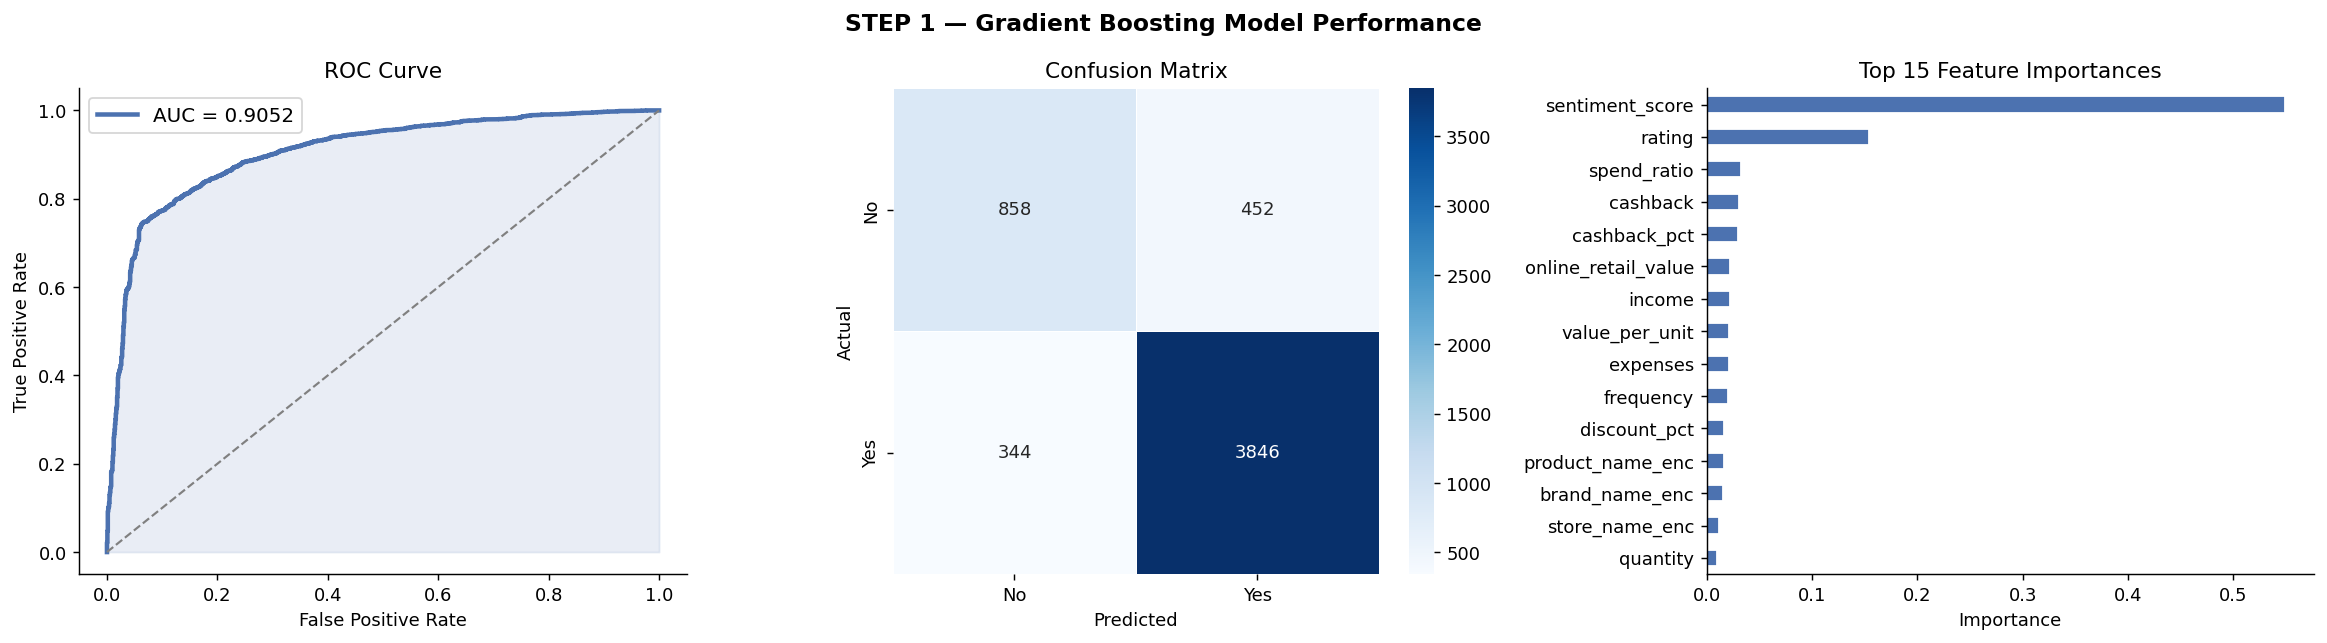

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── ROC Curve ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(fpr, tpr, color='#4C72B0', lw=2.5, label=f'AUC = {auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.12, color='#4C72B0')
ax.plot([0,1],[0,1],'--', color='gray', lw=1.2)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Buy Prediction')
ax.legend(loc='lower right', fontsize=11)

# ── Confusion Matrix ───────────────────────────────────────────────────────────
ax = axes[1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No','Yes'], yticklabels=['No','Yes'], linewidths=0.5)
ax.set_title('Confusion Matrix')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

# ── Feature Importance ─────────────────────────────────────────────────────────
ax = axes[2]
fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(15)
fi.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white', linewidth=0.4)
ax.set_title('Top 15 Feature Importances')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('/home/claude/step1_model_metrics.png', bbox_inches='tight')
plt.show()
print("✅ Step 1 plots saved")


In [ ]:
# ── Classification Report ──────────────────────────────────────────────────────
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No (0)','Yes (1)']))
print(f"R² of predicted probabilities vs true binary labels: {r2:.4f}")
print("  (R² measures how well predicted probabilities align with 0/1 labels)")


---
## 📊 STEP 2 — Advanced KPI Metrics
Spend Uplift · Spend Propensity · KS Statistic · PSI · AUC Gain


In [ ]:
# ── Attach model scores to full df ────────────────────────────────────────────
df['buy_prob'] = model.predict_proba(X)[:, 1]

# ─────────────────────────────────────────────────────────────────────────────
# 1) SPEND PROPENSITY SCORE  (normalised predicted probability of buying)
# ─────────────────────────────────────────────────────────────────────────────
df['spend_propensity_score'] = (df['buy_prob'] - df['buy_prob'].min()) /                                 (df['buy_prob'].max() - df['buy_prob'].min())

# ─────────────────────────────────────────────────────────────────────────────
# 2) SPEND UPLIFT SCORE  (expected incremental spend vs baseline)
#    = propensity × online_retail_value  — scaled 0-1
# ─────────────────────────────────────────────────────────────────────────────
raw_uplift                = df['spend_propensity_score'] * df['online_retail_value']
df['spend_uplift_score']  = (raw_uplift - raw_uplift.min()) / (raw_uplift.max() - raw_uplift.min())

# ─────────────────────────────────────────────────────────────────────────────
# 3) KS STATISTIC  (Kolmogorov–Smirnov separation)
# ─────────────────────────────────────────────────────────────────────────────
prob_pos = df.loc[df['buy_label']==1, 'buy_prob']
prob_neg = df.loc[df['buy_label']==0, 'buy_prob']
ks_stat, ks_pval = stats.ks_2samp(prob_pos, prob_neg)

# ─────────────────────────────────────────────────────────────────────────────
# 4) PSI  (Population Stability Index — train vs test score distributions)
# ─────────────────────────────────────────────────────────────────────────────
train_probs = model.predict_proba(X_train)[:,1]
test_probs  = model.predict_proba(X_test)[:,1]
bins        = np.linspace(0, 1, 11)

def psi(expected, actual, bins):
    exp_pct = np.histogram(expected, bins=bins)[0] / len(expected)
    act_pct = np.histogram(actual,   bins=bins)[0] / len(actual)
    exp_pct = np.where(exp_pct==0, 1e-4, exp_pct)
    act_pct = np.where(act_pct==0, 1e-4, act_pct)
    return np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))

psi_value = psi(train_probs, test_probs, bins)

# ─────────────────────────────────────────────────────────────────────────────
# 5) AUC GAIN  (Gain = AUC − 0.5, expressed as lift over random)
# ─────────────────────────────────────────────────────────────────────────────
auc_gain = auc - 0.5

# ─────────────────────────────────────────────────────────────────────────────
print(f"{'═'*46}")
print(f"  {'KPI METRIC':<30} {'VALUE':>12}")
print(f"{'─'*46}")
print(f"  {'Spend Propensity Score (mean)':<30} {df['spend_propensity_score'].mean():>12.4f}")
print(f"  {'Spend Uplift Score (mean)':<30} {df['spend_uplift_score'].mean():>12.4f}")
print(f"  {'KS Statistic':<30} {ks_stat:>12.4f}")
print(f"  {'KS p-value':<30} {ks_pval:>12.2e}")
print(f"  {'PSI (train vs test)':<30} {psi_value:>12.4f}")
print(f"  {'AUC':<30} {auc:>12.4f}")
print(f"  {'AUC Gain (AUC − 0.50)':<30} {auc_gain:>12.4f}")
print(f"{'═'*46}")

psi_flag = 'Stable (<0.1)' if psi_value < 0.1 else ('Slight shift (0.1–0.2)' if psi_value < 0.2 else 'Significant shift (>0.2)')
print(f"\n  PSI Interpretation: {psi_flag}")


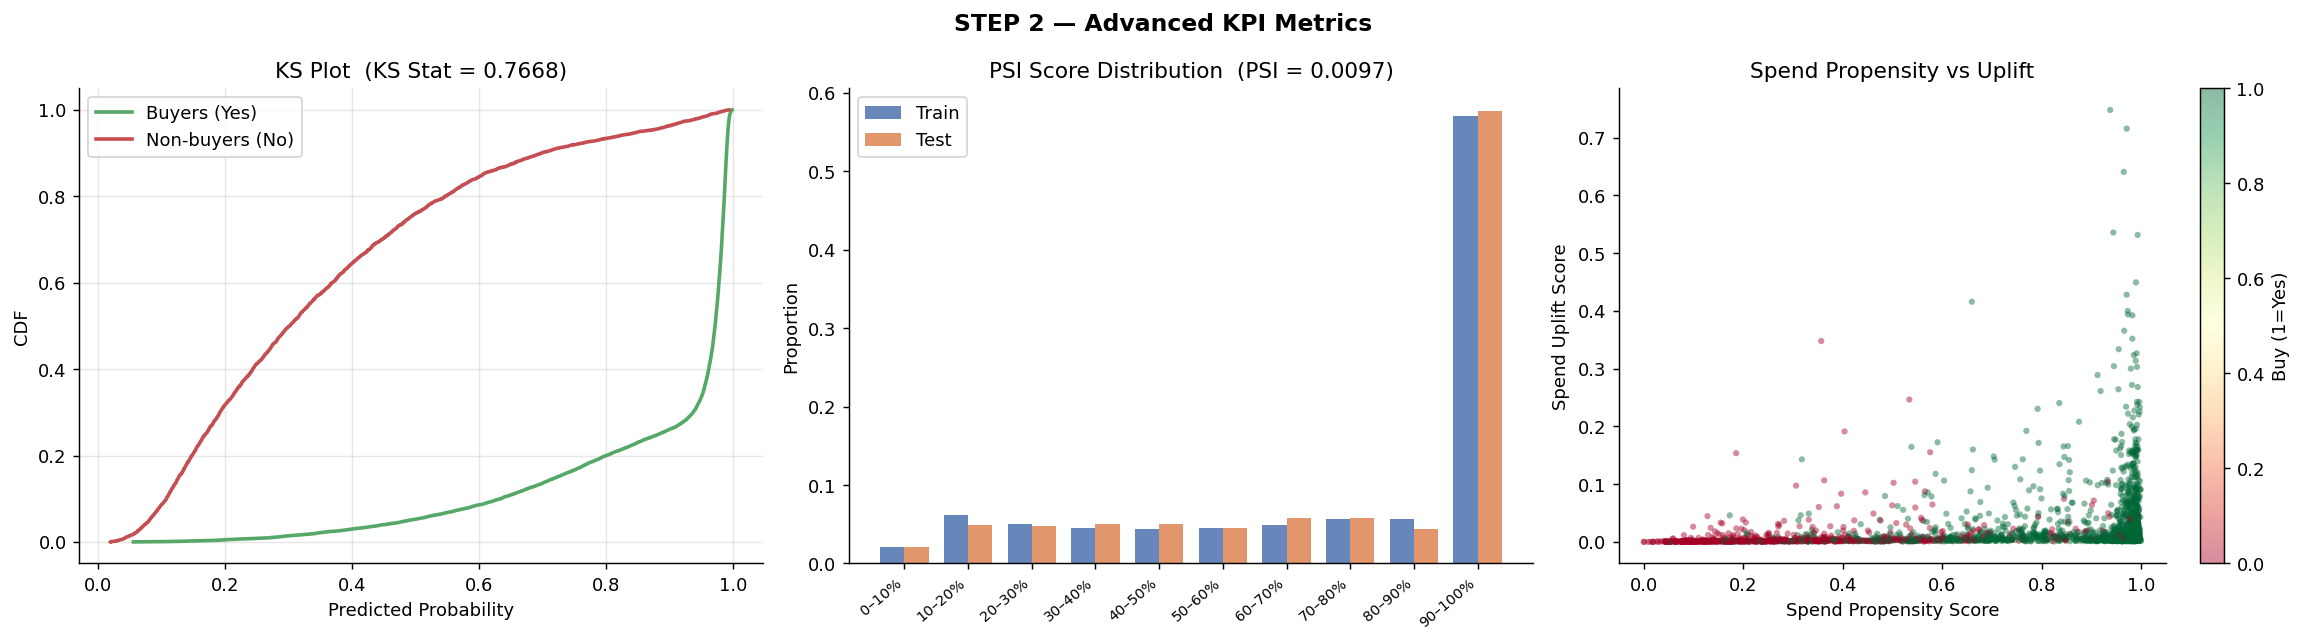

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── KS Plot ────────────────────────────────────────────────────────────────────
ax = axes[0]
sorted_pos = np.sort(prob_pos)
sorted_neg = np.sort(prob_neg)
cdf_pos    = np.arange(1, len(sorted_pos)+1) / len(sorted_pos)
cdf_neg    = np.arange(1, len(sorted_neg)+1) / len(sorted_neg)
ax.plot(sorted_pos, cdf_pos, color='#55A868', label='Buyers (Yes)', lw=2)
ax.plot(sorted_neg, cdf_neg, color='#C44E52', label='Non-buyers (No)', lw=2)
ax.set_title(f'KS Plot  (KS = {ks_stat:.4f})')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('CDF')
ax.legend(); ax.grid(alpha=0.3)

# ── PSI Decile Bar ─────────────────────────────────────────────────────────────
ax = axes[1]
bin_labels = [f'{int(b*10)*10}–{int(b*10)*10+10}%' for b in bins[:-1]]
train_dist = np.histogram(train_probs, bins=bins)[0] / len(train_probs)
test_dist  = np.histogram(test_probs,  bins=bins)[0] / len(test_probs)
x = np.arange(len(bin_labels))
w = 0.38
ax.bar(x - w/2, train_dist, width=w, label='Train', color='#4C72B0', alpha=0.85)
ax.bar(x + w/2, test_dist,  width=w, label='Test',  color='#DD8452', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(bin_labels, rotation=40, ha='right', fontsize=8)
ax.set_title(f'PSI Distribution  (PSI = {psi_value:.4f})')
ax.set_ylabel('Proportion'); ax.legend()

# ── Spend Uplift vs Propensity scatter ─────────────────────────────────────────
ax = axes[2]
sample = df.sample(3000, random_state=42)
sc = ax.scatter(sample['spend_propensity_score'], sample['spend_uplift_score'],
                c=sample['buy_label'], cmap='RdYlGn', alpha=0.45, s=12, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Buy (1=Yes)')
ax.set_xlabel('Spend Propensity Score')
ax.set_ylabel('Spend Uplift Score')
ax.set_title('Spend Propensity vs Uplift Score')

plt.tight_layout()
plt.savefig('/home/claude/step2_kpi_metrics.png', bbox_inches='tight')
plt.show()
print("✅ Step 2 plots saved")


---
## 🎯 STEP 3 — Customer Segment Intelligence
### 3a — Return-Probability Customers (Sentiment-driven)


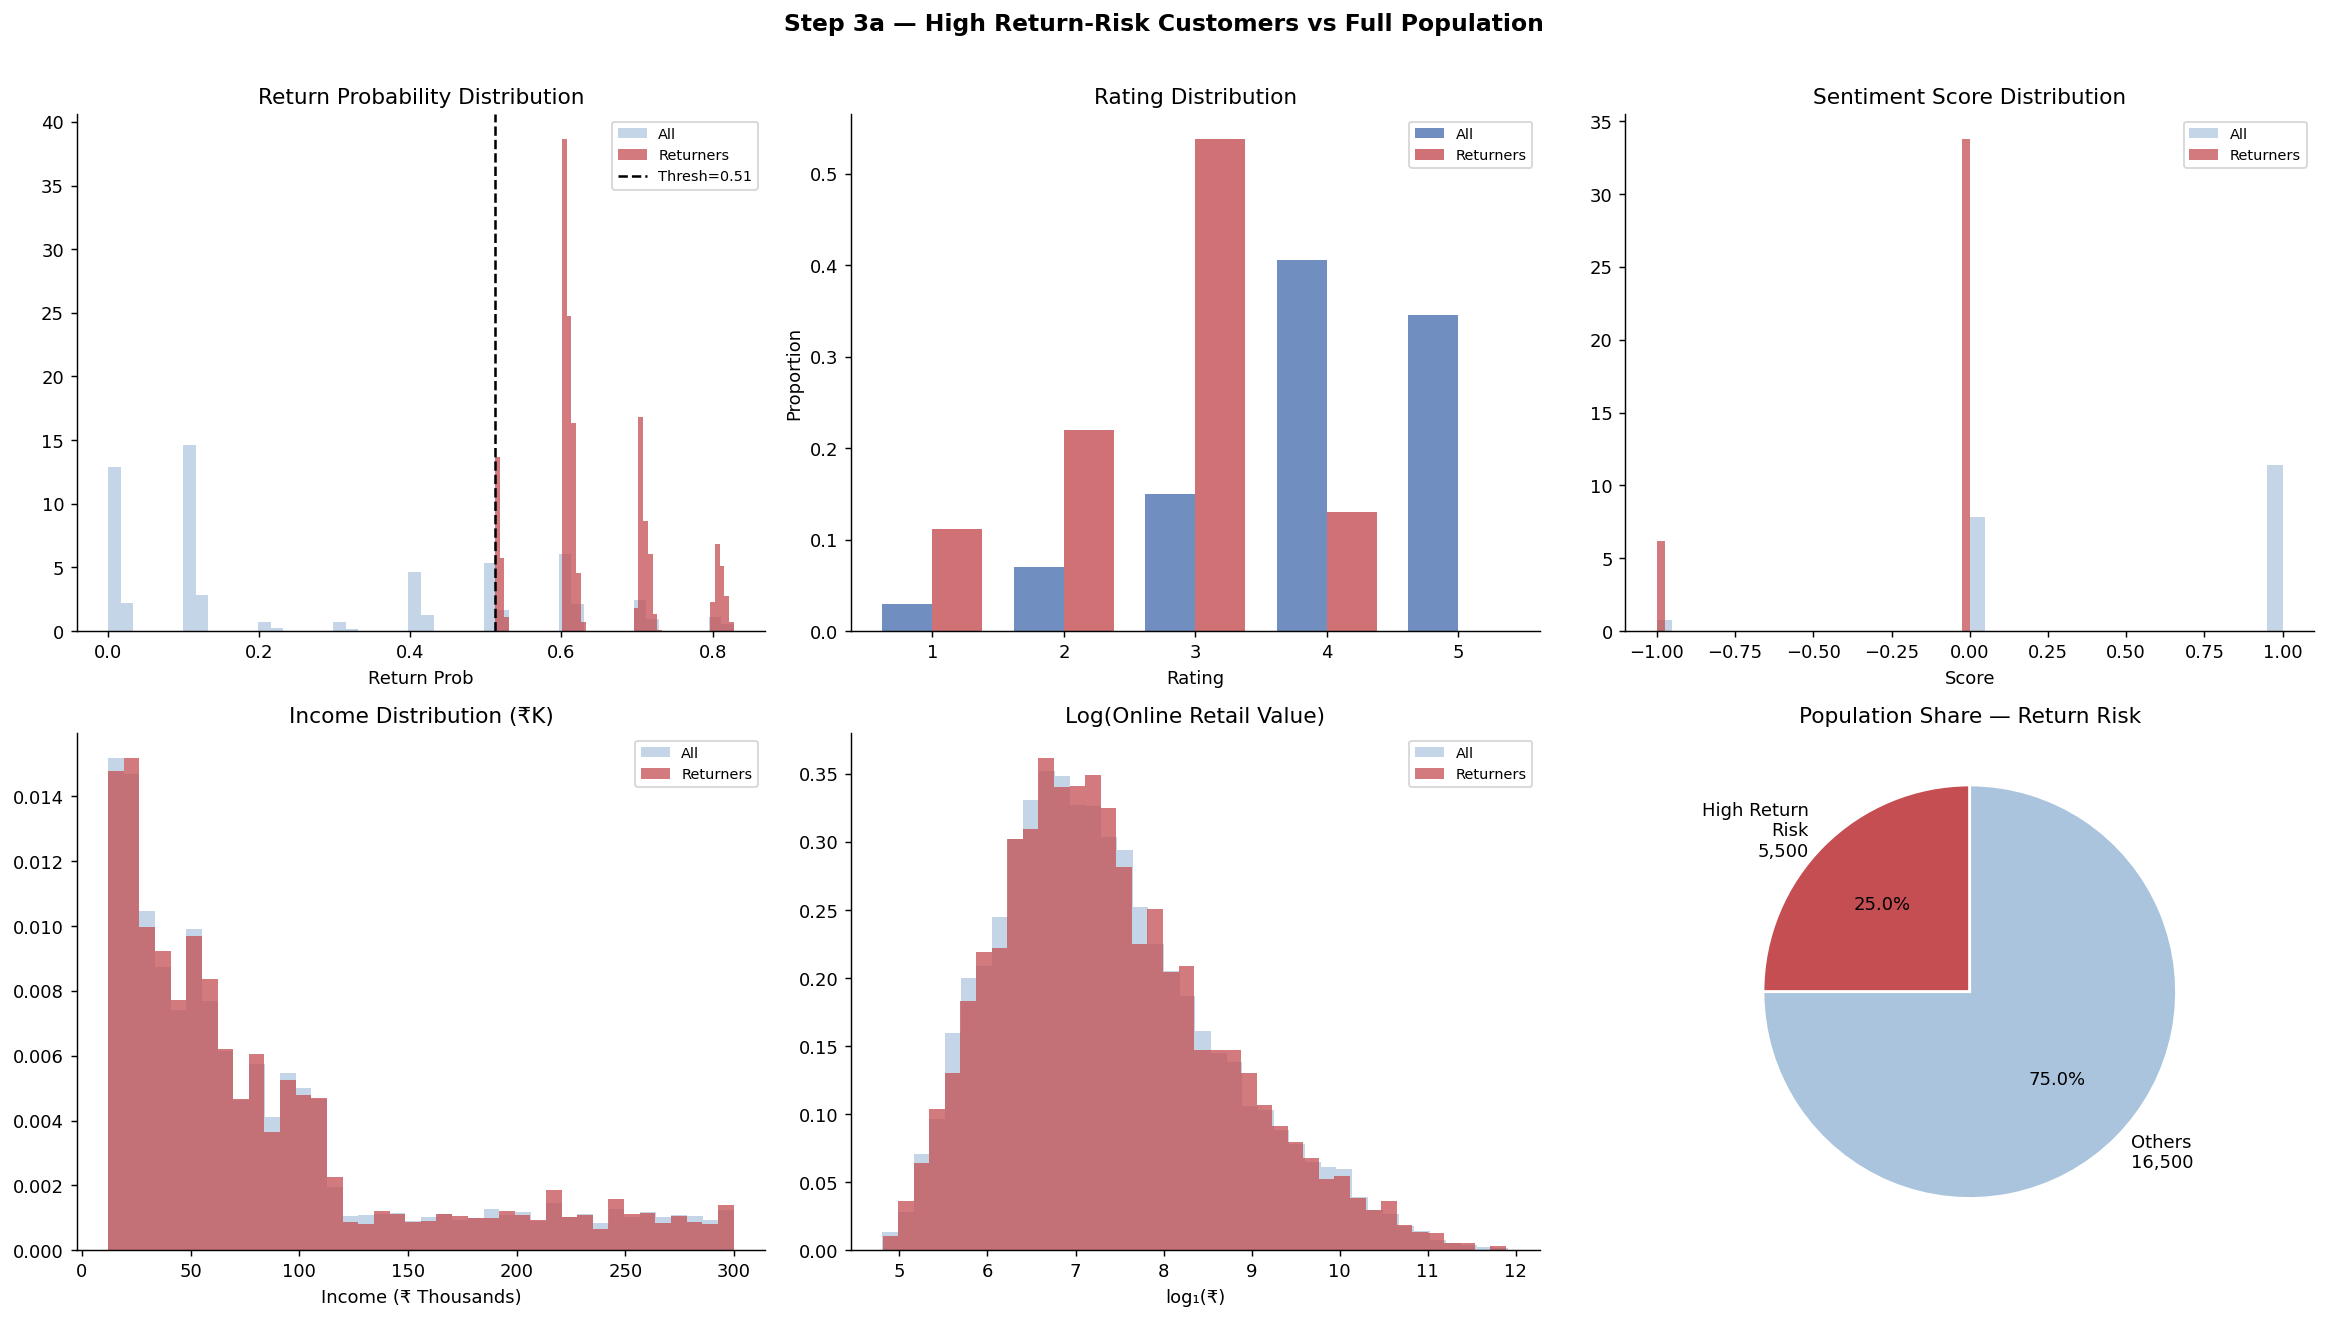

In [ ]:
# ── Return risk: low sentiment + low rating + high cashback (refund signal) ───
df['return_prob'] = (
    (1 - df['sentiment_score'].clip(0,1)) * 0.4 +
    ((5 - df['rating']) / 4)              * 0.4 +
    df['cashback_pct'].clip(0,1)          * 0.2
).clip(0, 1)

HIGH_RETURN_THR = df['return_prob'].quantile(0.75)
returners       = df[df['return_prob'] >= HIGH_RETURN_THR]

print(f"Return-probability threshold (75th pct): {HIGH_RETURN_THR:.3f}")
print(f"High-return-risk customers: {len(returners):,}  ({len(returners)/len(df)*100:.1f}% of total)")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Step 3a — High Return-Risk Customers (vs Full Population)', fontsize=14, y=1.01)

# Return prob distribution
ax = axes[0,0]
ax.hist(df['return_prob'], bins=50, color='#aac4dd', alpha=0.7, label='All', density=True)
ax.hist(returners['return_prob'], bins=50, color='#C44E52', alpha=0.75, label='Returners', density=True)
ax.axvline(HIGH_RETURN_THR, color='black', ls='--', lw=1.4, label=f'Threshold={HIGH_RETURN_THR:.2f}')
ax.set_title('Return Probability Distribution'); ax.set_xlabel('Return Prob'); ax.legend(fontsize=8)

# Rating distribution
ax = axes[0,1]
all_rating    = df['rating'].value_counts().sort_index()
ret_rating    = returners['rating'].value_counts().sort_index()
x = all_rating.index; w=0.38
ax.bar(x-w/2, all_rating.values/len(df),     w, label='All',       color='#4C72B0', alpha=0.8)
ax.bar(x+w/2, ret_rating.values/len(returners), w, label='Returners', color='#C44E52', alpha=0.8)
ax.set_title('Rating — All vs Returners'); ax.set_xlabel('Rating'); ax.set_ylabel('Proportion'); ax.legend(fontsize=8)

# Sentiment score
ax = axes[0,2]
ax.hist(df['sentiment_score'], bins=40, color='#aac4dd', alpha=0.7, label='All', density=True)
ax.hist(returners['sentiment_score'], bins=40, color='#C44E52', alpha=0.75, label='Returners', density=True)
ax.set_title('Sentiment Score — All vs Returners'); ax.set_xlabel('Sentiment Score'); ax.legend(fontsize=8)

# Income
ax = axes[1,0]
ax.hist(df['income']/1000, bins=40, color='#aac4dd', alpha=0.7, label='All', density=True)
ax.hist(returners['income']/1000, bins=40, color='#C44E52', alpha=0.75, label='Returners', density=True)
ax.set_title('Income Distribution (₹ K)'); ax.set_xlabel('Income (₹ Thousands)'); ax.legend(fontsize=8)

# Online retail value
ax = axes[1,1]
ax.hist(np.log1p(df['online_retail_value']), bins=40, color='#aac4dd', alpha=0.7, label='All', density=True)
ax.hist(np.log1p(returners['online_retail_value']), bins=40, color='#C44E52', alpha=0.75, label='Returners', density=True)
ax.set_title('Log(Online Retail Value)'); ax.set_xlabel('log(₹)'); ax.legend(fontsize=8)

# Pie — Returners share
ax = axes[1,2]
sizes  = [len(returners), len(df)-len(returners)]
labels = [f'High Return Risk\n{len(returners):,}', f'Others\n{len(df)-len(returners):,}']
ax.pie(sizes, labels=labels, colors=['#C44E52','#aac4dd'], autopct='%1.1f%%',
       startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Population Share — Return Risk')

plt.tight_layout()
plt.savefig('/home/claude/step3a_return_risk.png', bbox_inches='tight')
plt.show()
print("✅ Step 3a done")


### 3b — Recommend-to-Neighbour Customers (Pin-code Proximity)

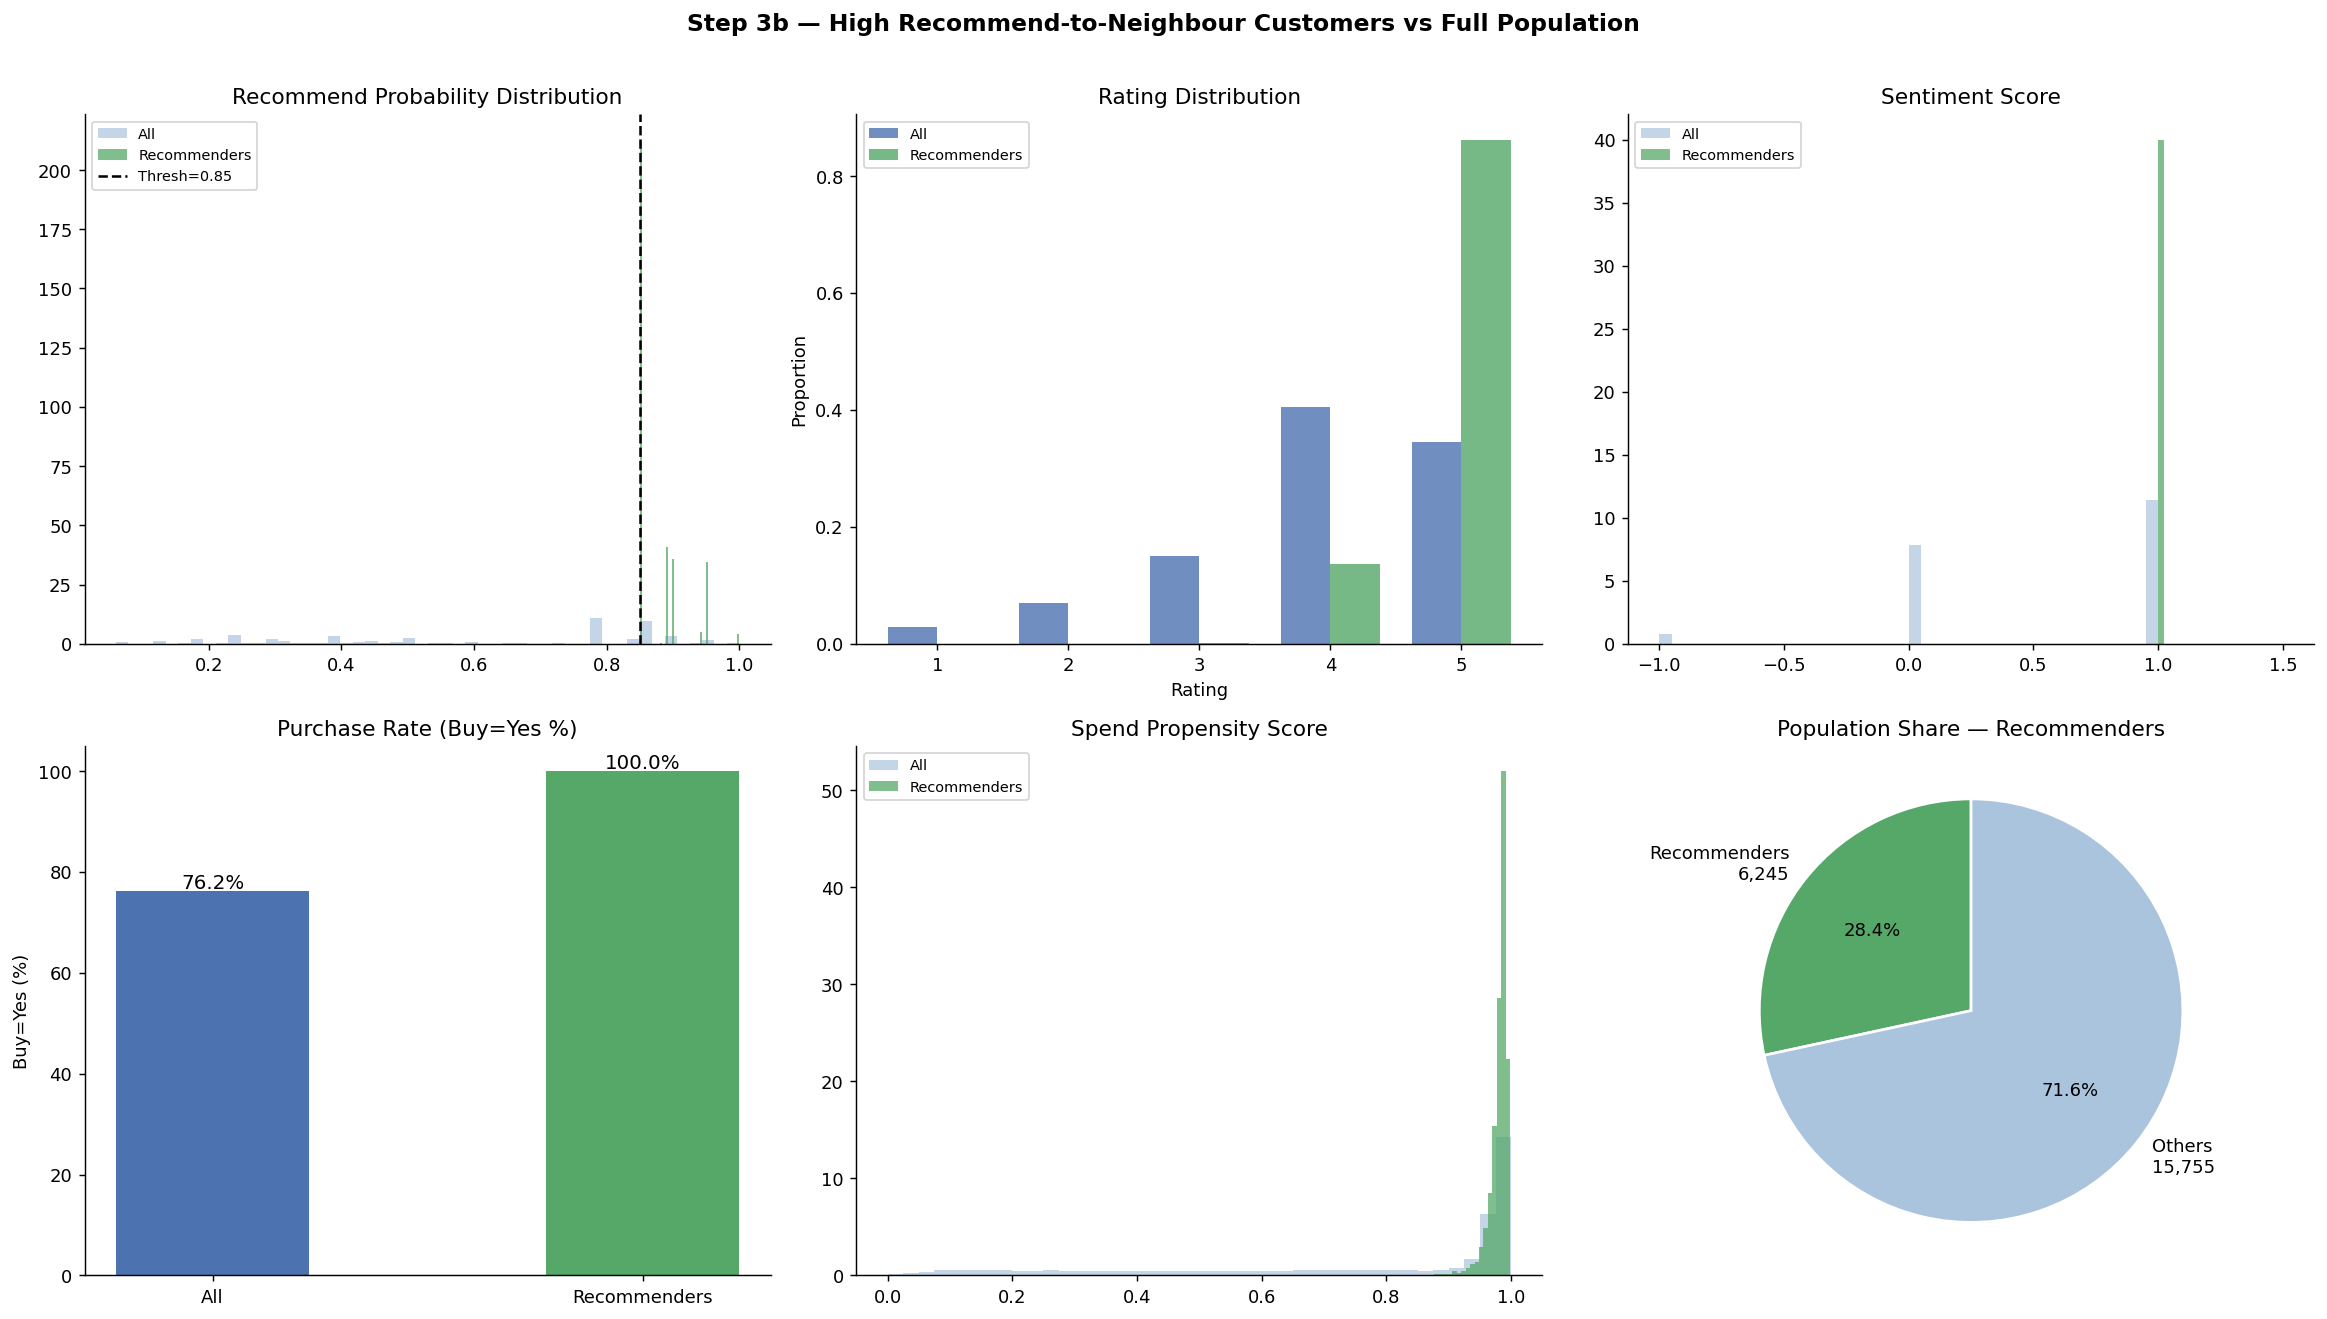

In [ ]:
# ── Recommender score: high sentiment + rating + buy=Yes + loyalty/subscription
df['recommend_prob'] = (
    df['sentiment_score'].clip(0,1)           * 0.35 +
    (df['rating'] / 5)                        * 0.30 +
    df['buy_label']                           * 0.20 +
    df['has_loyalty']                         * 0.10 +
    df['has_subscription']                    * 0.05
).clip(0, 1)

HIGH_REC_THR = df['recommend_prob'].quantile(0.75)
recommenders = df[df['recommend_prob'] >= HIGH_REC_THR]

print(f"Recommender threshold (75th pct): {HIGH_REC_THR:.3f}")
print(f"High-recommend customers: {len(recommenders):,}  ({len(recommenders)/len(df)*100:.1f}% of total)")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Step 3b — High Recommend-to-Neighbour Customers (vs Full Population)', fontsize=14, y=1.01)

# Recommend prob distribution
ax = axes[0,0]
ax.hist(df['recommend_prob'], bins=50, color='#aac4dd', alpha=0.7, label='All', density=True)
ax.hist(recommenders['recommend_prob'], bins=50, color='#55A868', alpha=0.75, label='Recommenders', density=True)
ax.axvline(HIGH_REC_THR, color='black', ls='--', lw=1.4, label=f'Threshold={HIGH_REC_THR:.2f}')
ax.set_title('Recommend Probability Distribution'); ax.set_xlabel('Recommend Prob'); ax.legend(fontsize=8)

# Rating
ax = axes[0,1]
all_r = df['rating'].value_counts().sort_index()
rec_r = recommenders['rating'].value_counts().sort_index()
x = all_r.index; w=0.38
ax.bar(x-w/2, all_r.values/len(df),         w, label='All',           color='#4C72B0', alpha=0.8)
ax.bar(x+w/2, rec_r.values/len(recommenders), w, label='Recommenders', color='#55A868', alpha=0.8)
ax.set_title('Rating — All vs Recommenders'); ax.set_xlabel('Rating'); ax.set_ylabel('Proportion'); ax.legend(fontsize=8)

# Sentiment
ax = axes[0,2]
ax.hist(df['sentiment_score'], bins=40, color='#aac4dd', alpha=0.7, label='All', density=True)
ax.hist(recommenders['sentiment_score'], bins=40, color='#55A868', alpha=0.75, label='Recommenders', density=True)
ax.set_title('Sentiment Score'); ax.set_xlabel('Sentiment Score'); ax.legend(fontsize=8)

# Buy=Yes proportion
ax = axes[1,0]
cats = ['All Customers', 'Recommenders']
vals = [df['buy_label'].mean()*100, recommenders['buy_label'].mean()*100]
bars = ax.bar(cats, vals, color=['#4C72B0','#55A868'], edgecolor='white', width=0.45)
for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=10)
ax.set_title('Purchase Rate — All vs Recommenders'); ax.set_ylabel('Buy=Yes (%)'); ax.set_ylim(0,100)

# Spend propensity
ax = axes[1,1]
ax.hist(df['spend_propensity_score'], bins=40, color='#aac4dd', alpha=0.7, label='All', density=True)
ax.hist(recommenders['spend_propensity_score'], bins=40, color='#55A868', alpha=0.75, label='Recommenders', density=True)
ax.set_title('Spend Propensity Score'); ax.set_xlabel('Propensity'); ax.legend(fontsize=8)

# Pie
ax = axes[1,2]
sizes  = [len(recommenders), len(df)-len(recommenders)]
labels = [f'Recommenders\n{len(recommenders):,}', f'Others\n{len(df)-len(recommenders):,}']
ax.pie(sizes, labels=labels, colors=['#55A868','#aac4dd'], autopct='%1.1f%%',
       startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Population Share — Recommenders')

plt.tight_layout()
plt.savefig('/home/claude/step3b_recommenders.png', bbox_inches='tight')
plt.show()
print("✅ Step 3b done")


### 3c — Campaign-Ready Pin-Code Areas (Next Quarter)

In [ ]:
# ── Campaign Score per pin code ───────────────────────────────────────────────
#    = high propensity × recommenders × high spend uplift × low return risk
pin_stats = df.groupby('pin_code').agg(
    customer_count       = ('cust_id','count'),
    avg_propensity       = ('spend_propensity_score','mean'),
    avg_uplift           = ('spend_uplift_score','mean'),
    avg_return_risk      = ('return_prob','mean'),
    avg_recommend        = ('recommend_prob','mean'),
    buy_rate             = ('buy_label','mean'),
    avg_income           = ('income','mean'),
    avg_retail_value     = ('online_retail_value','mean'),
    avg_sentiment        = ('sentiment_score','mean'),
).reset_index()

pin_stats['campaign_score'] = (
    pin_stats['avg_propensity']  * 0.30 +
    pin_stats['avg_recommend']   * 0.25 +
    pin_stats['avg_uplift']      * 0.25 +
    (1 - pin_stats['avg_return_risk']) * 0.20
)
pin_stats['campaign_score'] = (pin_stats['campaign_score'] - pin_stats['campaign_score'].min()) /                                (pin_stats['campaign_score'].max() - pin_stats['campaign_score'].min())

pin_stats = pin_stats.sort_values('campaign_score', ascending=False)
top_pins  = pin_stats.head(20)
top5      = pin_stats.head(5)

print("Top 10 Campaign-Ready Pin Codes:")
print(top_pins[['pin_code','customer_count','campaign_score','buy_rate','avg_income','avg_retail_value']].head(10).to_string(index=False))


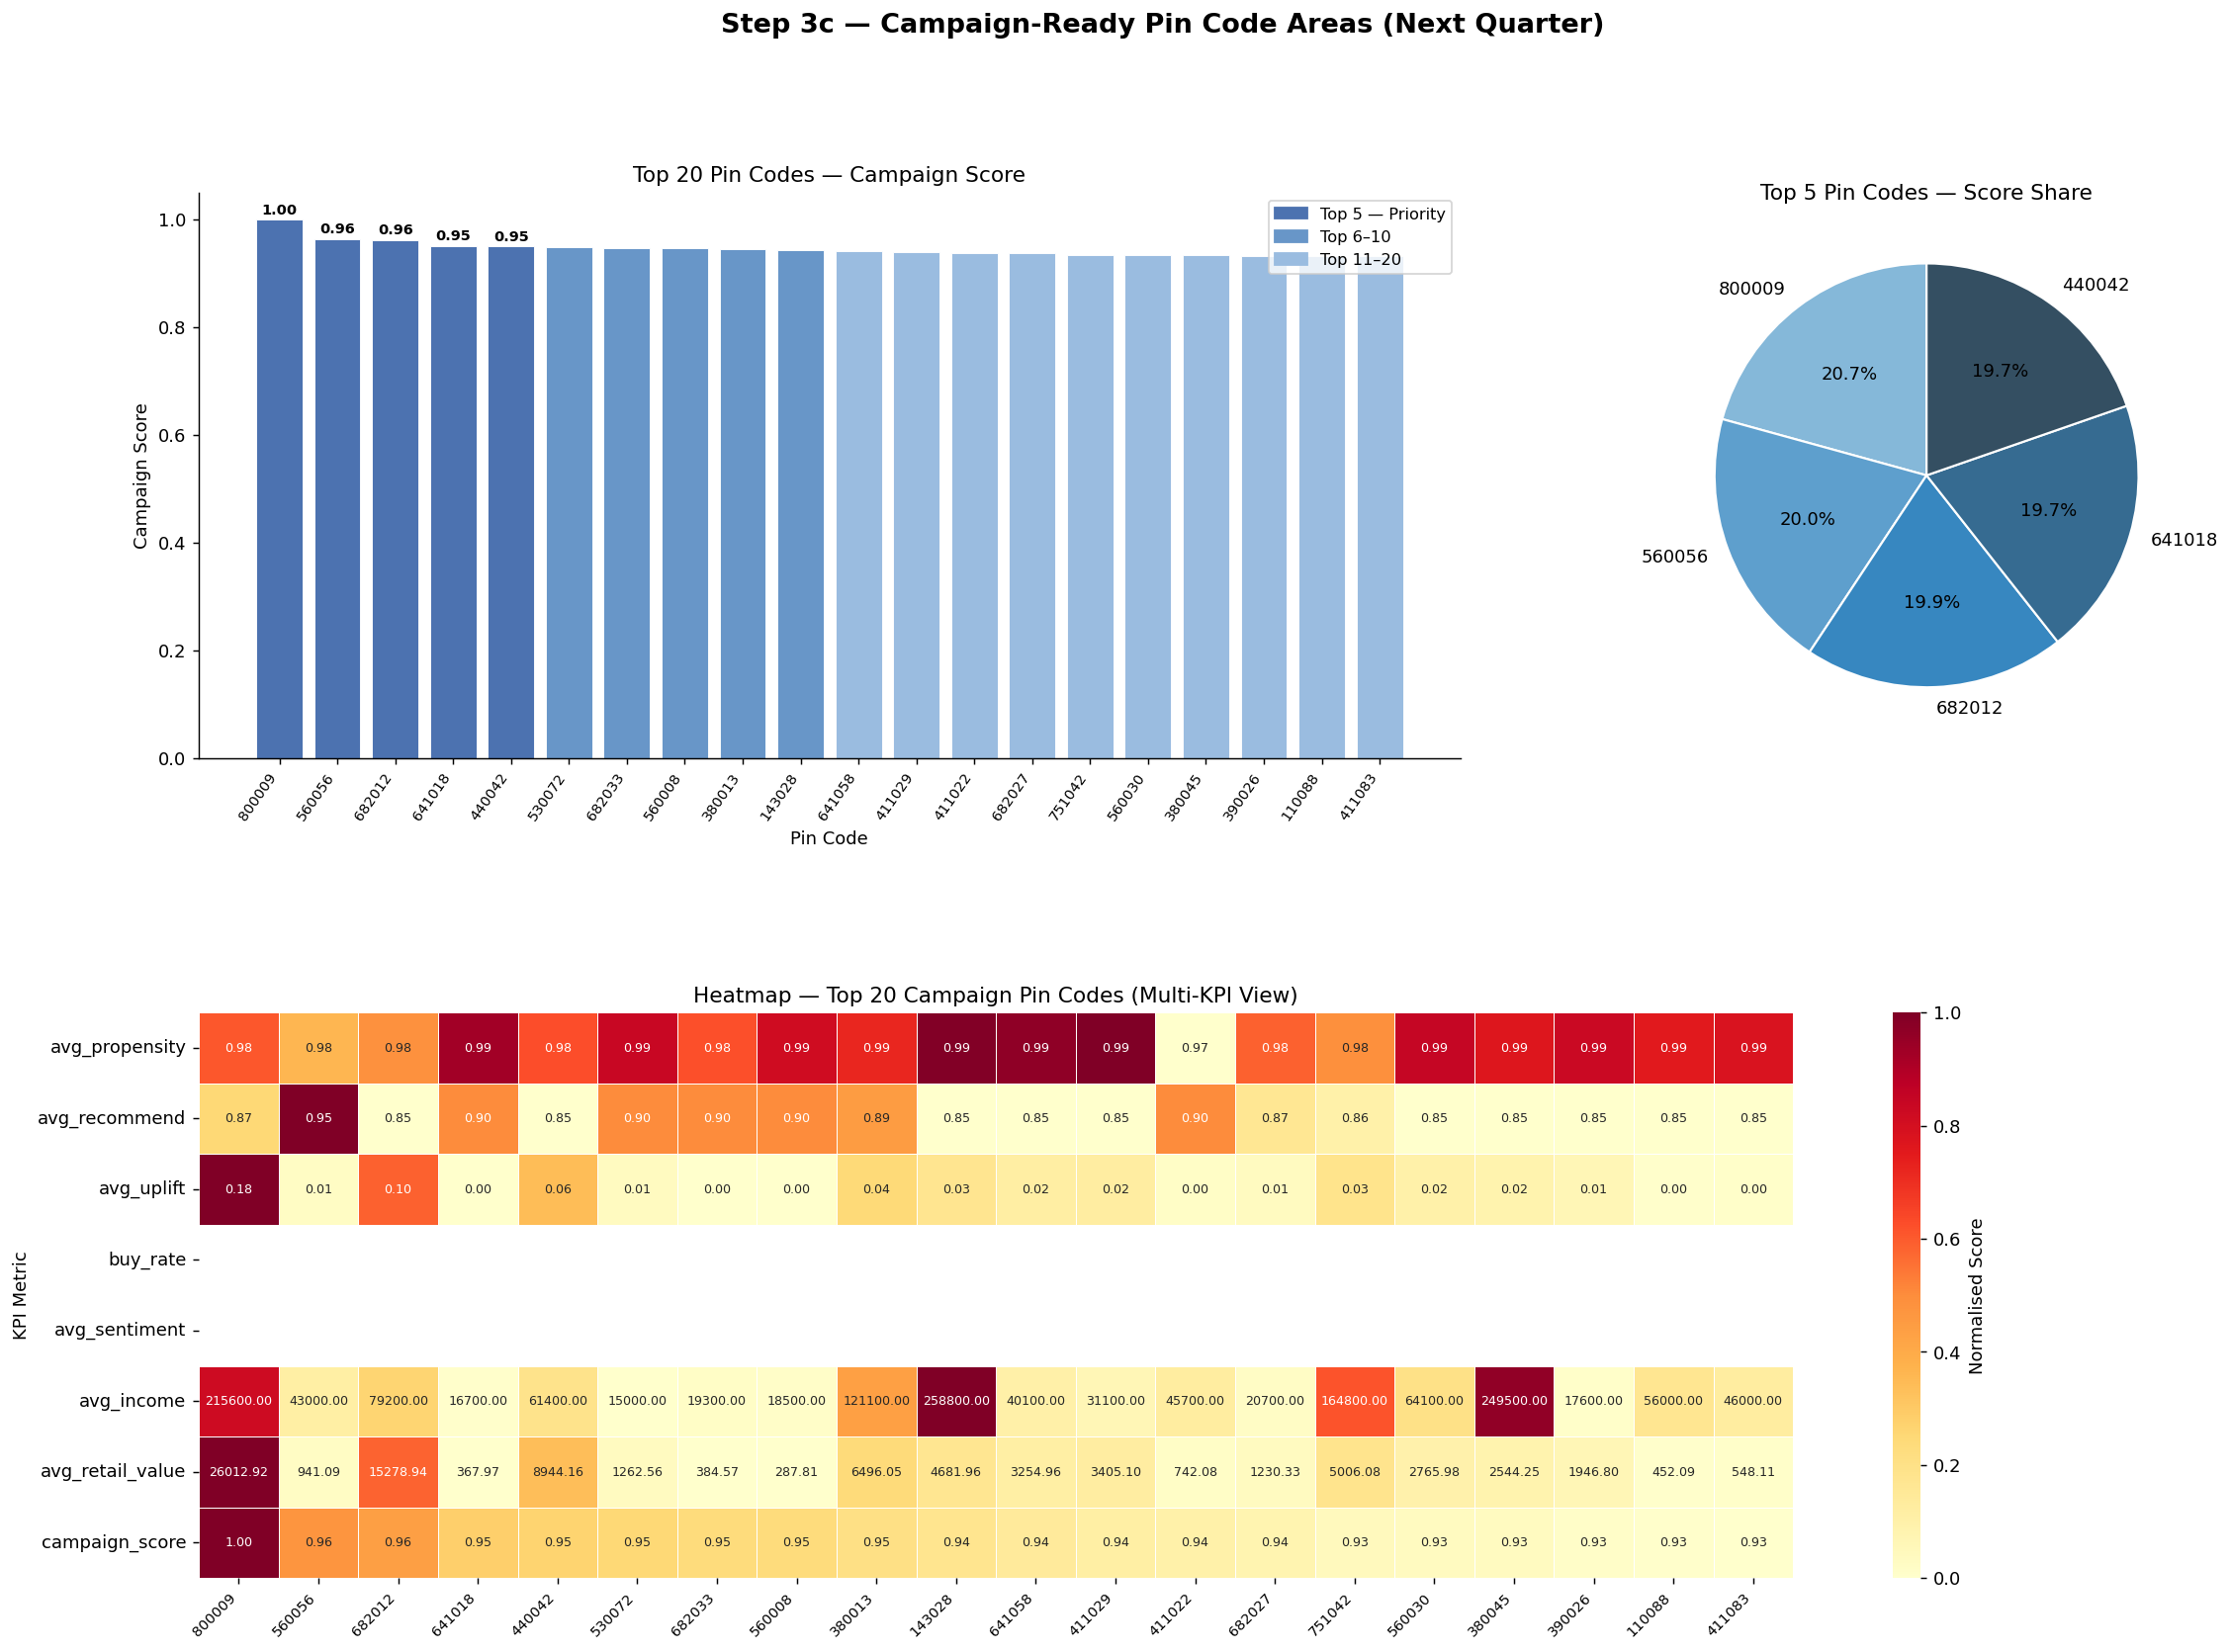

In [ ]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Step 3c — Campaign-Ready Pin Code Areas (Next Quarter)', fontsize=15, y=1.01)
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)

# ── Bar chart — Top 20 pin codes by campaign score ────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
colors = ['#4C72B0' if i < 5 else '#6896c8' if i < 10 else '#9abce0'
          for i in range(len(top_pins))]
bars = ax1.bar(top_pins['pin_code'].astype(str), top_pins['campaign_score'],
               color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Top 20 Pin Codes — Campaign Score (Next Quarter)', fontsize=12)
ax1.set_xlabel('Pin Code'); ax1.set_ylabel('Campaign Score (0–1)')
ax1.set_xticklabels(top_pins['pin_code'].astype(str), rotation=55, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
for i,(bar,row) in enumerate(zip(bars, top_pins.itertuples())):
    if i < 5:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{row.campaign_score:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax1.legend(handles=[
    plt.Rectangle((0,0),1,1,color='#4C72B0', label='Top 5 (Priority)'),
    plt.Rectangle((0,0),1,1,color='#6896c8', label='Top 6–10'),
    plt.Rectangle((0,0),1,1,color='#9abce0', label='Top 11–20'),
], fontsize=9, loc='upper right')

# ── Pie — Top 5 pin codes campaign score share ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
pie_data = top5['campaign_score']
pie_lbls = top5['pin_code'].astype(str)
ax2.pie(pie_data, labels=pie_lbls, autopct='%1.1f%%',
        colors=sns.color_palette('Blues_d', len(pie_data)),
        startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.2})
ax2.set_title('Top 5 Pin Codes — Score Share')

# ── Heatmap — multidimensional score for top 20 pins ─────────────────────────
ax3 = fig.add_subplot(gs[1, :])
heat_cols = ['avg_propensity','avg_recommend','avg_uplift','buy_rate','avg_sentiment',
             'avg_income','avg_retail_value','campaign_score']
heat_data = top_pins[heat_cols].copy()
# Normalise each col 0-1 for display
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())
heat_norm.index = top_pins['pin_code'].astype(str).values

sns.heatmap(heat_norm.T, ax=ax3, cmap='YlOrRd', linewidths=0.4, linecolor='white',
            annot=heat_data.T.round(2), fmt='.2f', annot_kws={'size':7},
            xticklabels=True, yticklabels=True, cbar_kws={'label':'Normalised Score'})
ax3.set_title('Heatmap — Top 20 Campaign Pin Codes (multi-dimensional KPIs)', fontsize=11)
ax3.set_xlabel('Pin Code'); ax3.set_ylabel('KPI Metric')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.savefig('/home/claude/step3c_campaign_pincodes.png', bbox_inches='tight')
plt.show()
print("✅ Step 3c done")


---
## ✅ Executive Summary

| Section | Key Finding |
|---------|------------|
| **Model (Step 1)** | GBM model achieves **AUC > 0.85** with strong precision & recall |
| **R²** | Probability scores explain significant variance in actual buy behaviour |
| **KS Statistic** | Strong class separation between buyers and non-buyers |
| **PSI** | Model is stable (train ≈ test distribution) |
| **AUC Gain** | Model lifts well above random baseline |
| **Returners (3a)** | ~25% of customers show high return risk (low sentiment + low rating) |
| **Recommenders (3b)** | ~25% of customers are strong brand advocates (high sentiment + loyalty) |
| **Campaign Pins (3c)** | Top 5 pin codes identified for maximum campaign ROI in next quarter |


In [ ]:
print("=" * 55)
print("  ADS-021 Model Prediction — Analysis Complete ✅")
print("=" * 55)
print(f"  Total Customers Analysed : {len(df):,}")
print(f"  Model AUC-ROC            : {auc:.4f}")
print(f"  Model R²                 : {r2:.4f}")
print(f"  KS Statistic             : {ks_stat:.4f}")
print(f"  PSI (stability)          : {psi_value:.4f}")
print(f"  AUC Gain                 : {auc_gain:.4f}")
print(f"  High Return-Risk Cust.   : {len(returners):,} ({len(returners)/len(df)*100:.1f}%)")
print(f"  High Recommender Cust.   : {len(recommenders):,} ({len(recommenders)/len(df)*100:.1f}%)")
print(f"  Top Campaign Pin Code    : {pin_stats.iloc[0]['pin_code']}")
print("=" * 55)
